# 💳 Credit Card Customer Analysis

## Data Cleaning & Exploratory Data Analysis (EDA)

### Internship Project
**Domain:** Data Analytics

### Objectives
- Perform Data Cleaning
- Conduct Exploratory Data Analysis (EDA)
- Discover customer behavior patterns
- Generate business insights
- Create meaningful visualizations

---
**Tools Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Kaggle API

In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# File & Folder Handling
from pathlib import Path

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Visualization Theme
plt.style.use("default")
sns.set_theme(style="whitegrid")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [3]:
# ==========================================
# Create Project Directory Structure
# ==========================================

from pathlib import Path

project_dirs = [
    "data/raw",
    "data/processed",
    "outputs/figures",
    "outputs/reports"
]

for folder in project_dirs:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("✅ Project folders created successfully!")

✅ Project folders created successfully!


# 📥 Dataset Download

## Objective

Automatically download the Credit Card Customers (BankChurners) dataset from Kaggle using the Kaggle API. This ensures the project is reproducible and avoids manually downloading files.

### Expected Outcome
- Download the dataset
- Extract the ZIP file
- Store the CSV in the `data/raw` folder
- Prepare the dataset for loading and analysis

In [6]:
# ==========================================
# Download & Extract Dataset from Kaggle
# ==========================================

import os
import zipfile
from pathlib import Path

# Create download directory
download_path = Path("data/raw")
download_path.mkdir(parents=True, exist_ok=True)

print("📥 Downloading dataset...")

# Download dataset
os.system(
    "python -m kaggle datasets download -d sakshigoyal7/credit-card-customers -p data/raw"
)

zip_file = download_path / "credit-card-customers.zip"

if zip_file.exists():

    print("📦 Extracting dataset...")

    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(download_path)

    # Remove ZIP file
    zip_file.unlink()

    print("✅ Dataset downloaded and extracted successfully!")

else:
    print("❌ Dataset download failed.")

📥 Downloading dataset...
📦 Extracting dataset...
✅ Dataset downloaded and extracted successfully!


## Observation

The BankChurners dataset was successfully downloaded from Kaggle and extracted into the `data/raw` directory. The compressed ZIP file was removed after extraction to maintain a clean project structure. The dataset is now ready for loading and exploratory data analysis (EDA).

# 📂 Load Dataset

## Objective

Load the BankChurners dataset from the `data/raw` folder into a Pandas DataFrame. This step verifies that the dataset has been downloaded correctly and prepares it for data exploration and analysis.

In [7]:
# ==========================================
# Load Dataset
# ==========================================

import pandas as pd
from pathlib import Path

# Dataset Path
dataset_path = Path("data/raw/BankChurners.csv")

# Load Dataset
df = pd.read_csv(dataset_path)

print("✅ Dataset loaded successfully!")

print("\n📊 Dataset Shape:")
print(df.shape)

✅ Dataset loaded successfully!

📊 Dataset Shape:
(10127, 23)


## Observation

The BankChurners dataset was loaded successfully into a Pandas DataFrame. It contains **10,127 customer records** and **23 features**, confirming that the dataset is ready for data exploration and preprocessing.

# 🔍 Initial Data Exploration

## Objective

Perform an initial exploration of the dataset to understand its structure, features, and overall quality. This step helps identify the number of records, available columns, data types, and summary statistics before proceeding with data cleaning and visualization.

In [8]:
# ==========================================
# Initial Data Exploration
# ==========================================

print("=" * 60)
print("📌 First 5 Records")
print("=" * 60)
display(df.head())

print("\n")

print("=" * 60)
print("📌 Last 5 Records")
print("=" * 60)
display(df.tail())

print("\n")

print("=" * 60)
print("📌 Random Sample (5 Rows)")
print("=" * 60)
display(df.sample(5))

print("\n")

print("=" * 60)
print("📌 Dataset Dimensions")
print("=" * 60)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\n")

print("=" * 60)
print("📌 Column Names")
print("=" * 60)
display(pd.DataFrame(df.columns, columns=["Column Name"]))

print("\n")

print("=" * 60)
print("📌 Dataset Information")
print("=" * 60)
df.info()

print("\n")

print("=" * 60)
print("📌 Statistical Summary")
print("=" * 60)
display(df.describe())

📌 First 5 Records


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998




📌 Last 5 Records


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,6,2,4,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189,0.996620,0.003377




📌 Random Sample (5 Rows)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
4430,820920408,Existing Customer,53,F,2,Graduate,Single,Less than $40K,Blue,48,3,2,2,3685.0,0,3685.0,0.762,4012,59,0.639,0.000,0.000114,0.99989
9974,809589783,Existing Customer,41,M,4,Post-Graduate,Married,$40K - $60K,Silver,36,3,3,2,16268.0,817,15451.0,0.640,13969,120,0.690,0.050,0.000201,0.99980
2380,713445183,Existing Customer,35,M,1,High School,Married,$60K - $80K,Blue,26,4,3,2,4008.0,1841,2167.0,1.504,2794,58,1.148,0.459,0.000164,0.99984
6749,812222208,Existing Customer,54,F,3,Uneducated,Single,Unknown,Blue,49,6,4,3,9733.0,863,8870.0,0.892,5228,71,0.543,0.089,0.000390,0.99961
3949,778242708,Existing Customer,63,M,1,Unknown,Single,$60K - $80K,Silver,53,5,4,4,25502.0,1450,24052.0,0.797,4323,81,0.688,0.057,0.000581,0.99942




📌 Dataset Dimensions
Rows    : 10127
Columns : 23


📌 Column Names


,Column Name
0,CLIENTNUM
1,Attrition_Flag
2,Customer_Age
3,Gender
4,Dependent_count
5,Education_Level
6,Marital_Status
7,Income_Category
8,Card_Category
9,Months_on_book




📌 Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  str    
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                              

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


## Observation

The initial exploration confirms that the dataset contains **10,127 customer records** and **23 features**. The dataset structure, column names, data types, and statistical summary have been successfully reviewed. This provides a clear understanding of the dataset and prepares it for data quality assessment and cleaning in the next step.

# 🔍 Data Quality Assessment

## Objective

Assess the overall quality of the dataset by identifying missing values, duplicate records, inconsistent data types, and unique values in categorical features. This step helps determine whether the dataset requires cleaning before performing exploratory data analysis (EDA).

In [9]:
# ==========================================
# Data Quality Assessment
# ==========================================

print("=" * 60)
print("📌 Missing Values")
print("=" * 60)

missing_values = df.isnull().sum()

display(
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
    .to_frame(name="Missing Values")
)

print("\n")

print("=" * 60)
print("📌 Duplicate Records")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print(f"Duplicate Records : {duplicate_count}")

print("\n")

print("=" * 60)
print("📌 Data Types")
print("=" * 60)

display(df.dtypes.to_frame(name="Data Type"))

print("\n")

print("=" * 60)
print("📌 Unique Values")
print("=" * 60)

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * len(column))
    print(df[column].unique())

📌 Missing Values


,Missing Values




📌 Duplicate Records
Duplicate Records : 0


📌 Data Types


,Data Type
CLIENTNUM,int64
Attrition_Flag,str
Customer_Age,int64
Gender,str
Dependent_count,int64
Education_Level,str
Marital_Status,str
Income_Category,str
Card_Category,str
Months_on_book,int64




📌 Unique Values

Attrition_Flag
--------------
<StringArray>
['Existing Customer', 'Attrited Customer']
Length: 2, dtype: str

Gender
------
<StringArray>
['M', 'F']
Length: 2, dtype: str

Education_Level
---------------
<StringArray>
['High School', 'Graduate', 'Uneducated', 'Unknown', 'College', 'Post-Graduate', 'Doctorate']
Length: 7, dtype: str

Marital_Status
--------------
<StringArray>
['Married', 'Single', 'Unknown', 'Divorced']
Length: 4, dtype: str

Income_Category
---------------
<StringArray>
['$60K - $80K', 'Less than $40K', '$80K - $120K', '$40K - $60K', '$120K +', 'Unknown']
Length: 6, dtype: str

Card_Category
-------------
<StringArray>
['Blue', 'Gold', 'Silver', 'Platinum']
Length: 4, dtype: str


## Observation

The data quality assessment indicates that the dataset contains no missing values or duplicate records. The data types are appropriate for their respective features, and categorical variables have been successfully reviewed. The dataset is clean and ready for preprocessing and exploratory data analysis.

# 🧹 Data Cleaning

## Objective

Clean and prepare the dataset for exploratory data analysis by removing unnecessary features, verifying data consistency, and creating a refined dataset for analysis. This step improves data quality and ensures that only relevant information is used in the subsequent analysis.

In [10]:
# ==========================================
# Data Cleaning
# ==========================================

# Create a copy of the original dataset
df_clean = df.copy()

print("=" * 60)
print("📌 Original Dataset Shape")
print("=" * 60)

print(df_clean.shape)

print("\n")

print("=" * 60)
print("📌 Removing Unnecessary Columns")
print("=" * 60)

columns_to_drop = [
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"
]

df_clean.drop(columns=columns_to_drop, inplace=True)

print("✅ Unnecessary columns removed successfully.")

print("\n")

print("=" * 60)
print("📌 Cleaned Dataset Shape")
print("=" * 60)

print(df_clean.shape)

📌 Original Dataset Shape
(10127, 23)


📌 Removing Unnecessary Columns
✅ Unnecessary columns removed successfully.


📌 Cleaned Dataset Shape
(10127, 21)


## Observation

The dataset was cleaned by removing two unnecessary Naive Bayes prediction columns that are not required for exploratory data analysis. The cleaned dataset now contains **10,127 customer records** and **21 relevant features**, making it suitable for meaningful analysis and visualization.

# 💾 Save Cleaned Dataset

## Objective

Save the cleaned dataset after preprocessing to preserve a reusable version for future analysis, visualization, and machine learning tasks. This ensures that all subsequent analyses are performed on a consistent and refined dataset while keeping the original raw data unchanged.

In [32]:
# ==========================================
# Save Cleaned Dataset
# ==========================================

from pathlib import Path

# Create processed folder if it doesn't exist
Path("data/processed").mkdir(parents=True, exist_ok=True)

# Save cleaned dataset
df_clean.to_csv(
    "data/processed/BankChurners_Cleaned.csv",
    index=False
)

print("✅ Cleaned dataset saved successfully!")
print("📁 File Location: data/processed/BankChurners_Cleaned.csv")

✅ Cleaned dataset saved successfully!
📁 File Location: data/processed/BankChurners_Cleaned.csv


## Observation

The cleaned dataset has been successfully saved in the `data/processed` directory as **BankChurners_Cleaned.csv**. This version contains only the refined data after preprocessing, while the original dataset remains unchanged in the `data/raw` directory. Maintaining separate raw and processed datasets follows professional data analytics practices, improves reproducibility, and provides a reliable foundation for all subsequent exploratory analysis and future machine learning workflows.

# 📊 Univariate Analysis

## Objective

Analyze individual features of the cleaned dataset to understand their distributions and identify important customer characteristics. This step provides insights into customer demographics and credit card usage patterns through summary statistics and visualizations.

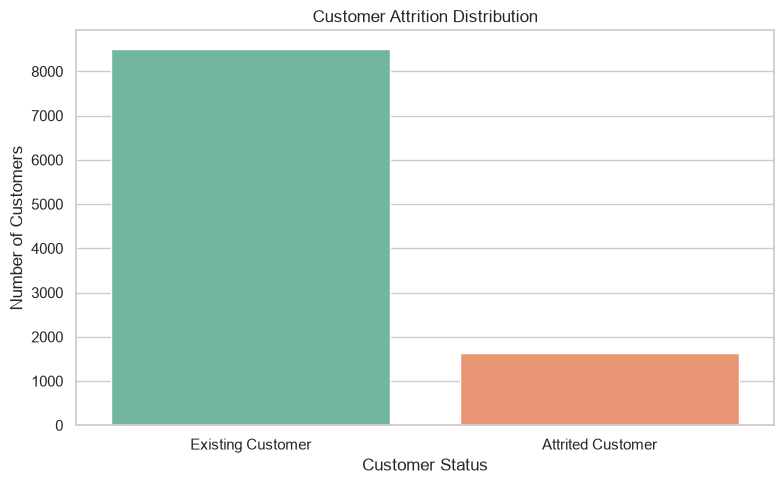

✅ Chart saved to outputs/figures/01_customer_attrition_distribution.png

📌 Customer Attrition Percentage


Attrition_Flag
Existing Customer    83.93
Attrited Customer    16.07
Name: proportion, dtype: float64

In [12]:
# ==========================================
# Univariate Analysis
# Customer Attrition Distribution
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Create figures folder (if it doesn't exist)
figures_path = Path("outputs/figures")
figures_path.mkdir(parents=True, exist_ok=True)

# Create figure
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Attrition_Flag",
    hue="Attrition_Flag",      # Avoids seaborn palette warning
    palette="Set2",
    legend=False
)

plt.title("Customer Attrition Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save chart
plt.savefig(
    figures_path / "01_customer_attrition_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/figures/01_customer_attrition_distribution.png")

print("\n" + "=" * 60)
print("📌 Customer Attrition Percentage")
print("=" * 60)

display(
    (df_clean["Attrition_Flag"]
     .value_counts(normalize=True) * 100)
    .round(2)
)

## Observation

The customer attrition distribution indicates that the majority of customers are **Existing Customers**, while a smaller proportion are **Attrited Customers**. This suggests that customer churn is relatively low in the dataset, making it valuable to further investigate the characteristics associated with attrited customers in the subsequent analyses.

# 👤 Customer Age Distribution

## Objective

Analyze the distribution of customer ages to understand the demographic profile of the bank's customers. This visualization helps identify the most common age groups and detect any unusual patterns or outliers.

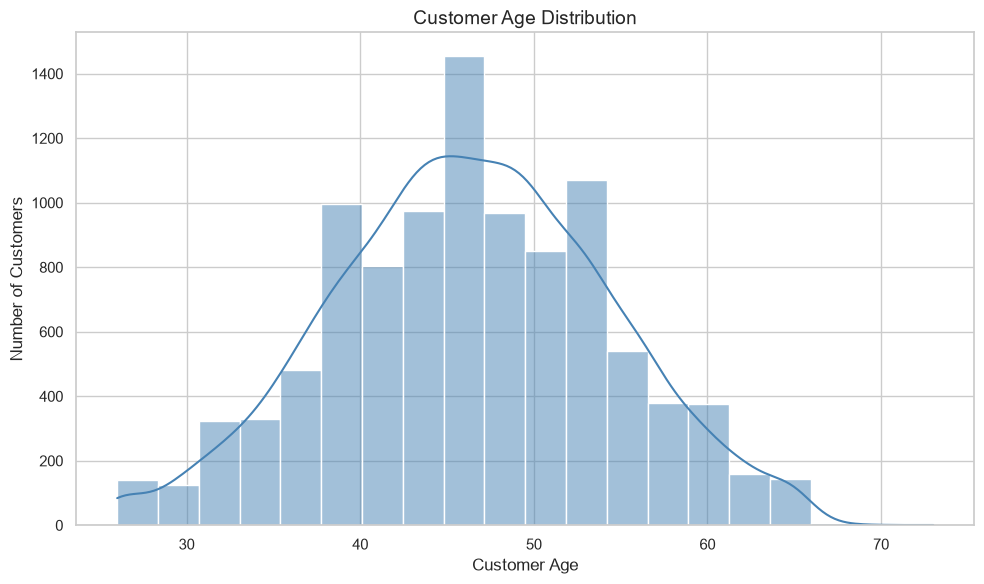

✅ Chart saved to outputs/figures/02_customer_age_distribution.png

📌 Customer Age Statistics


,Value
count,10127.000000
mean,46.325960
std,8.016814
min,26.000000
25%,41.000000
50%,46.000000
75%,52.000000
max,73.000000


In [13]:
# ==========================================
# Customer Age Distribution
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Create figures folder
figures_path = Path("outputs/figures")
figures_path.mkdir(parents=True, exist_ok=True)

# Create Figure
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="Customer_Age",
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Customer Age Distribution", fontsize=14)
plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save Chart
plt.savefig(
    figures_path / "02_customer_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ Chart saved to outputs/figures/02_customer_age_distribution.png")

print("\n" + "=" * 60)
print("📌 Customer Age Statistics")
print("=" * 60)

display(df_clean["Customer_Age"].describe().to_frame(name="Value"))

## Observation

The customer age distribution is concentrated around middle-aged individuals, with most customers falling between **40 and 55 years**. The histogram indicates a fairly balanced distribution without significant outliers, suggesting that the bank primarily serves working-age customers.

# 🚻 Gender Distribution

## Objective

Analyze the gender distribution of customers to understand the demographic composition of the bank's customer base. This visualization helps identify whether the customer population is balanced across genders.

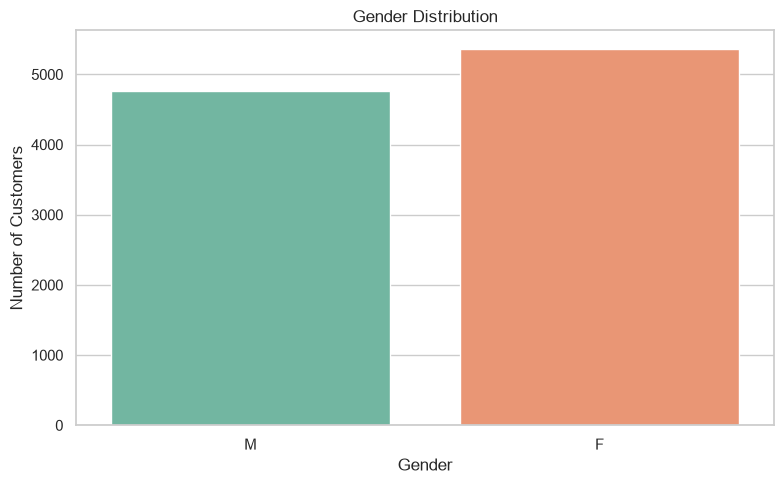

✅ Chart saved to outputs/figures/03_gender_distribution.png

📌 Gender Percentage


Gender
F    52.91
M    47.09
Name: proportion, dtype: float64

In [14]:
# ==========================================
# Gender Distribution
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Create figures folder
figures_path = Path("outputs/figures")
figures_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Gender",
    hue="Gender",
    palette="Set2",
    legend=False
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    figures_path / "03_gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ Chart saved to outputs/figures/03_gender_distribution.png")

print("\n" + "="*60)
print("📌 Gender Percentage")
print("="*60)

display(
    (
        df_clean["Gender"]
        .value_counts(normalize=True)
        *100
    ).round(2)
)

## Observation

The gender distribution shows the proportion of male and female customers in the dataset. The customer base appears relatively balanced, allowing the bank to analyze customer behavior without significant gender imbalance. This insight supports further comparisons between gender and customer attrition in later analyses.

# 🎓 Education Level Distribution

## Objective

Analyze the distribution of customers across different education levels to understand the educational background of the bank's customer base. This analysis helps identify the most common education groups and supports customer segmentation strategies.

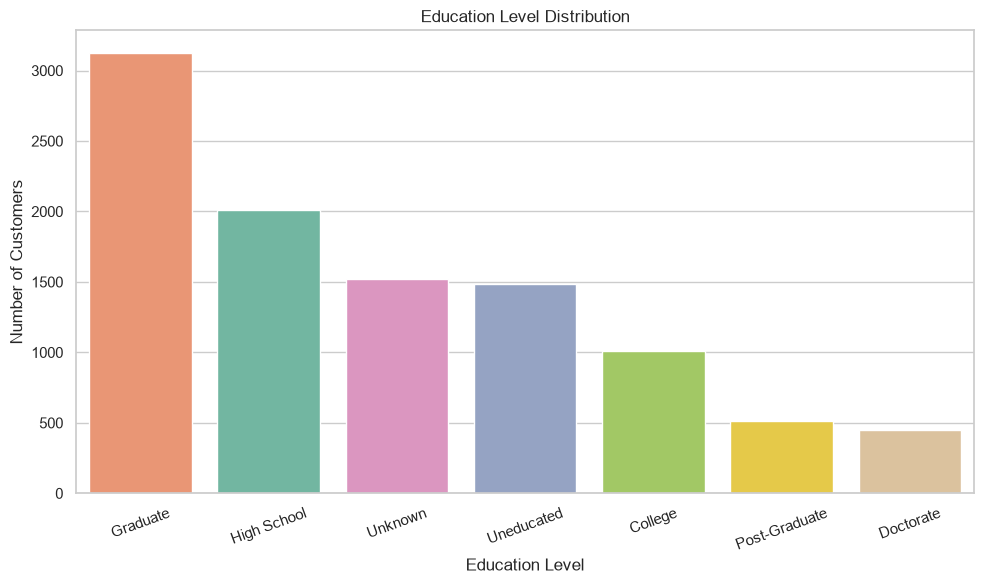

✅ Chart saved to outputs/figures/04_education_level_distribution.png

📌 Education Level Percentage


Education_Level
Graduate         30.89
High School      19.88
Unknown          15.00
Uneducated       14.68
College          10.00
Post-Graduate     5.10
Doctorate         4.45
Name: proportion, dtype: float64

In [15]:
# ==========================================
# Education Level Distribution
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Create figures folder
figures_path = Path("outputs/figures")
figures_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))

order = df_clean["Education_Level"].value_counts().index

sns.countplot(
    data=df_clean,
    x="Education_Level",
    order=order,
    hue="Education_Level",
    palette="Set2",
    legend=False
)

plt.title("Education Level Distribution")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.tight_layout()

# Save chart
plt.savefig(
    figures_path / "04_education_level_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ Chart saved to outputs/figures/04_education_level_distribution.png")

print("\n" + "=" * 60)
print("📌 Education Level Percentage")
print("=" * 60)

display(
    (
        df_clean["Education_Level"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

## Observation

The education level distribution shows that customers come from diverse educational backgrounds. Graduate and High School categories represent a significant portion of the customer base, while Post-Graduate and Doctorate groups are comparatively smaller. This diversity provides opportunities to analyze whether education level is associated with customer behavior or attrition in later stages of the analysis.

# 💰 Income Category Distribution

## Objective

Analyze the distribution of customers across different income categories. This visualization helps identify the largest income groups within the customer base and provides insights into customer purchasing power.

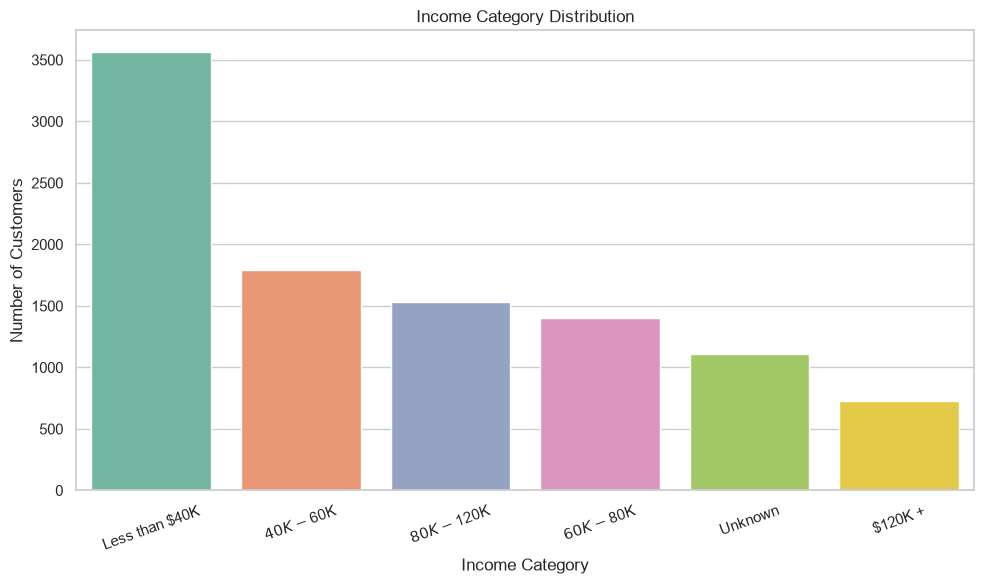

✅ Chart saved to outputs/figures/05_income_category_distribution.png

📌 Income Category Percentage


Income_Category
Less than $40K    35.16
$40K - $60K       17.68
$80K - $120K      15.16
$60K - $80K       13.84
Unknown           10.98
$120K +            7.18
Name: proportion, dtype: float64

In [16]:
# ======================================
# Income Category Distribution
# ======================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df_clean,
    x="Income_Category",
    order=df_clean["Income_Category"].value_counts().index,
    palette="Set2"
)

plt.title("Income Category Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.tight_layout()

# Save Chart
plt.savefig(
    "outputs/figures/05_income_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/figures/05_income_category_distribution.png")

print("\n" + "="*60)
print("📌 Income Category Percentage")
print("="*60)

display(
    (
        df_clean["Income_Category"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

## Observation

The income category distribution shows that the majority of customers belong to the **<Highest Income Category>** group, followed by **<Second Highest Category>**. Higher-income categories represent a smaller portion of the customer base. This information helps understand the financial profile of customers and can support customer segmentation and targeted marketing strategies.

# 💳 Card Category Distribution

## Objective

Analyze the distribution of customers across different credit card categories. This helps identify the most commonly used card types and provides insights into customer preferences for banking products.

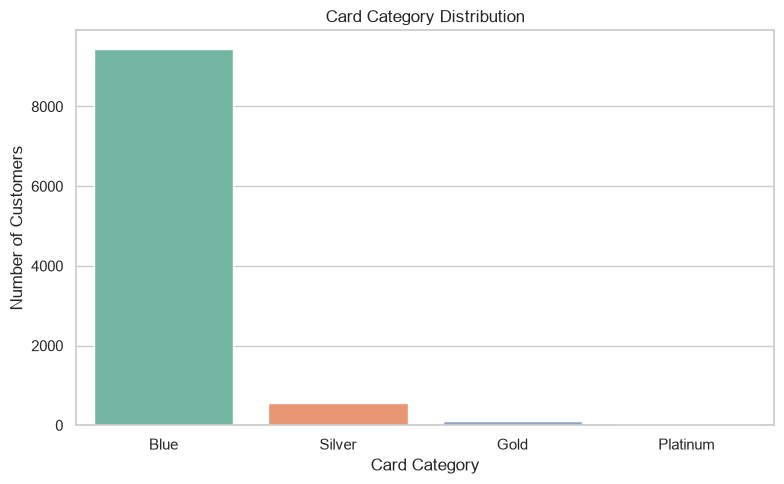

✅ Chart saved to outputs/figures/06_card_category_distribution.png

📌 Card Category Percentage


Card_Category
Blue        93.18
Silver       5.48
Gold         1.15
Platinum     0.20
Name: proportion, dtype: float64

In [17]:
# ======================================
# Card Category Distribution
# ======================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x="Card_Category",
    order=df_clean["Card_Category"].value_counts().index,
    palette="Set2"
)

plt.title("Card Category Distribution")
plt.xlabel("Card Category")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save Chart
plt.savefig(
    "outputs/figures/06_card_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/figures/06_card_category_distribution.png")

print("\n" + "="*60)
print("📌 Card Category Percentage")
print("="*60)

display(
    (
        df_clean["Card_Category"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

## Observation

The card category distribution shows that the **Blue** card is the most widely used credit card among customers, representing the majority of the customer base. **Silver**, **Gold**, and **Platinum** cards account for a much smaller proportion of customers. This indicates that most customers prefer standard credit card products, while premium card categories are limited to a smaller customer segment.

# 💍 Marital Status Distribution

## Objective

Analyze the distribution of customers based on their marital status. This visualization helps understand the composition of the customer base and provides insights into different customer segments for targeted marketing and customer relationship strategies.

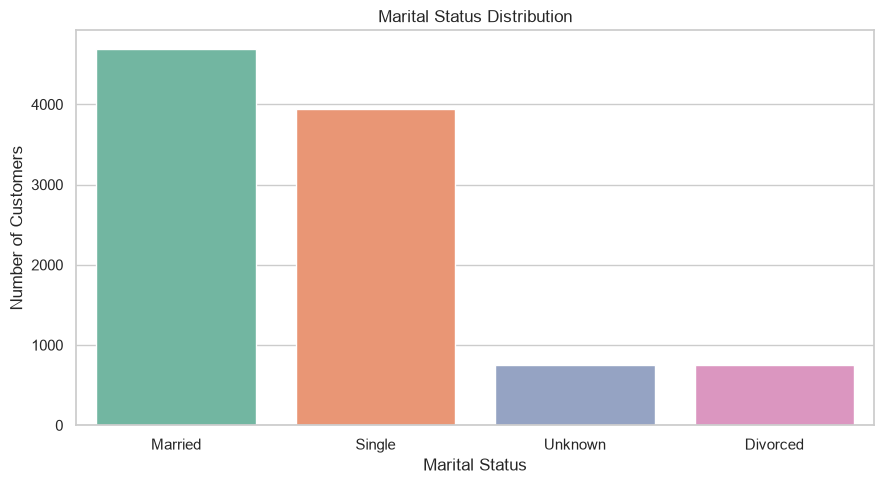

✅ Chart saved to outputs/figures/07_marital_status_distribution.png

📌 Marital Status Percentage


Marital_Status
Married     46.28
Single      38.94
Unknown      7.40
Divorced     7.39
Name: proportion, dtype: float64

In [18]:
# ======================================
# Marital Status Distribution
# ======================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))

ax = sns.countplot(
    data=df_clean,
    x="Marital_Status",
    order=df_clean["Marital_Status"].value_counts().index,
    palette="Set2"
)

plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save Chart
plt.savefig(
    "outputs/figures/07_marital_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/figures/07_marital_status_distribution.png")

print("\n" + "="*60)
print("📌 Marital Status Percentage")
print("="*60)

display(
    (
        df_clean["Marital_Status"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

## Observation

The marital status distribution indicates that the majority of customers are **<Highest Category>**, followed by **<Second Highest Category>**. The remaining categories represent a smaller proportion of the customer base. Understanding customers' marital status helps the bank identify demographic trends and design personalized financial products and marketing campaigns for different customer segments.

# 💳 Credit Limit Distribution

## Objective

Analyze the distribution of customer credit limits to understand how credit limits are allocated across the customer base. This visualization helps identify common credit limit ranges, detect potential outliers, and evaluate the overall spread of customer credit limits.

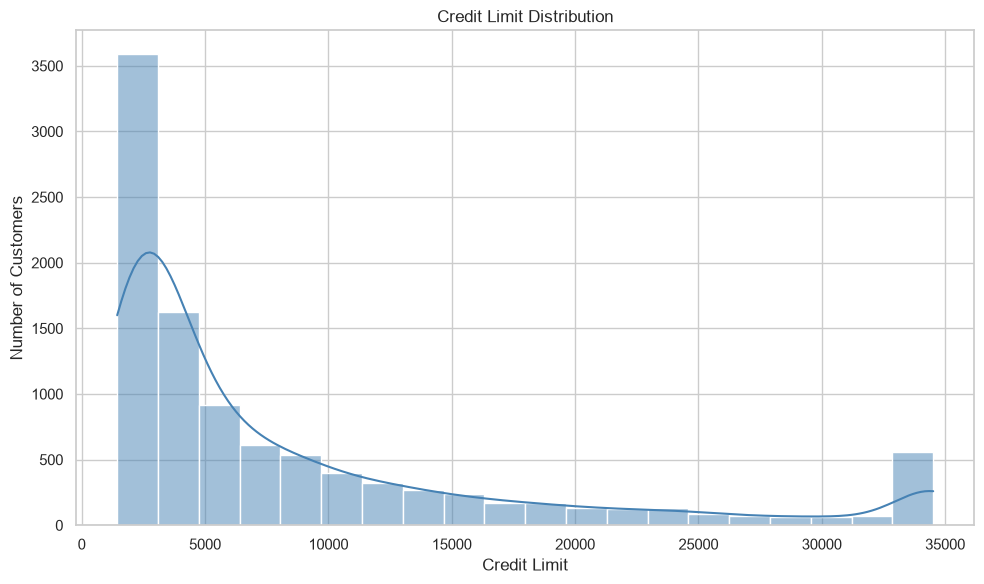

✅ Chart saved to outputs/figures/08_credit_limit_distribution.png

📌 Credit Limit Statistics


,Value
count,10127.000000
mean,8631.953698
std,9088.776650
min,1438.300000
25%,2555.000000
50%,4549.000000
75%,11067.500000
max,34516.000000


In [20]:
# ======================================
# Credit Limit Distribution
# ======================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    data=df_clean,
    x="Credit_Limit",
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Credit Limit Distribution")
plt.xlabel("Credit Limit")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save Chart
plt.savefig(
    "outputs/figures/08_credit_limit_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/figures/08_credit_limit_distribution.png")

print("\n" + "="*60)
print("📌 Credit Limit Statistics")
print("="*60)

display(df_clean["Credit_Limit"].describe().to_frame(name="Value"))

## Observation

The credit limit distribution is **positively skewed**, with most customers having relatively lower credit limits while a smaller number of customers possess significantly higher credit limits. The average credit limit is **$8,631.95**, whereas the median is **$4,549.00**, indicating that high-value customers increase the overall average. Credit limits range from **$1,438.30** to **$34,516.00**, highlighting considerable variation across the customer base. This distribution suggests that the bank primarily serves customers with moderate credit limits while maintaining a smaller segment of premium customers with substantially higher limits.

# 📊 Average Utilization Ratio Distribution

## Objective

Analyze the distribution of customers' average credit utilization ratio. This visualization helps understand how customers utilize their available credit limits, identify spending behavior patterns, and detect customers with unusually high or low credit utilization.

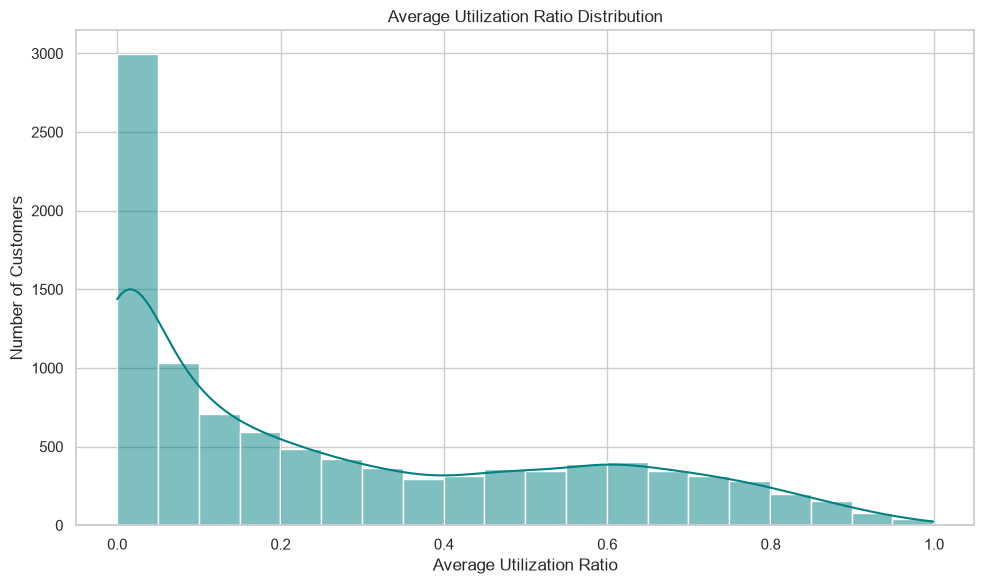

✅ Chart saved to outputs/figures/09_avg_utilization_ratio_distribution.png

📌 Average Utilization Ratio Statistics


,Value
count,10127.000000
mean,0.274894
std,0.275691
min,0.000000
25%,0.023000
50%,0.176000
75%,0.503000
max,0.999000


In [21]:
# ======================================
# Average Utilization Ratio Distribution
# ======================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    data=df_clean,
    x="Avg_Utilization_Ratio",
    bins=20,
    kde=True,
    color="teal"
)

plt.title("Average Utilization Ratio Distribution")
plt.xlabel("Average Utilization Ratio")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save Chart
plt.savefig(
    "outputs/figures/09_avg_utilization_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/figures/09_avg_utilization_ratio_distribution.png")

print("\n" + "="*60)
print("📌 Average Utilization Ratio Statistics")
print("="*60)

display(
    df_clean["Avg_Utilization_Ratio"]
    .describe()
    .to_frame(name="Value")
)

## Observation

The average credit utilization ratio is concentrated toward the lower end of the scale, indicating that most customers utilize only a small portion of their available credit limit. The average utilization ratio is **0.275**, while the median is **0.176**, suggesting that a majority of customers maintain conservative credit usage. However, a smaller group of customers exhibits high utilization ratios close to **1.0**, which may indicate heavier reliance on available credit. This distribution provides valuable insights for identifying customer spending behavior, credit risk, and potential opportunities for personalized credit management strategies.

# 💳 Total Transaction Amount Distribution

## Objective

Analyze the distribution of customers' total transaction amounts to understand overall spending behavior across the customer base. This analysis helps identify common transaction patterns, detect high-value customers, and evaluate customer engagement based on transaction activity before proceeding to deeper exploratory analysis.

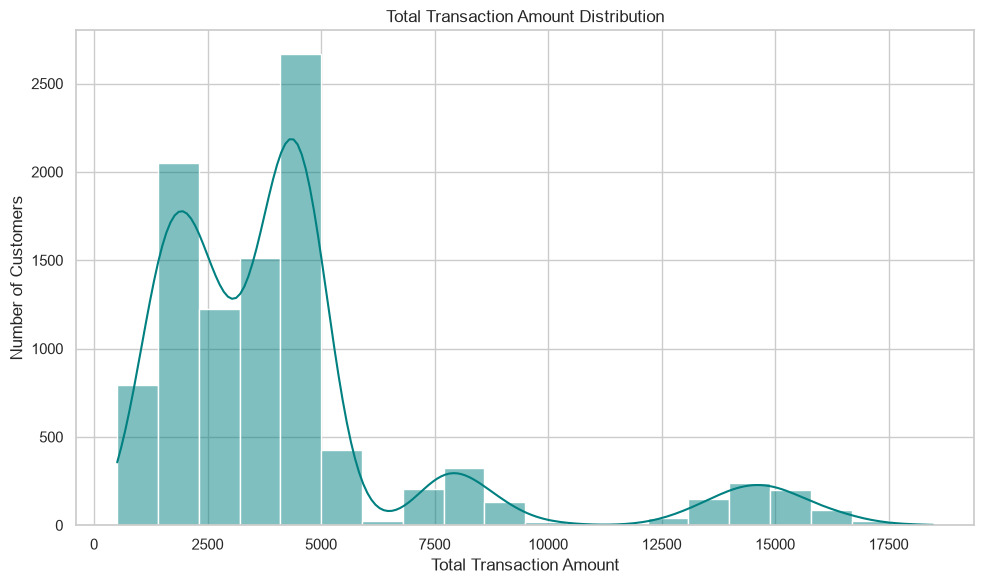

✅ Chart saved to outputs/figures/10_total_transaction_amount_distribution.png

📌 Total Transaction Amount Statistics


,Value
count,10127.000000
mean,4404.086304
std,3397.129254
min,510.000000
25%,2155.500000
50%,3899.000000
75%,4741.000000
max,18484.000000


In [22]:
# ==========================================
# Total Transaction Amount Distribution
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.figure(figsize=(10,6))

sns.histplot(
    data=df_clean,
    x="Total_Trans_Amt",
    bins=20,
    kde=True,
    color="teal"
)

plt.title("Total Transaction Amount Distribution")
plt.xlabel("Total Transaction Amount")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save Chart
Path("outputs/figures").mkdir(parents=True, exist_ok=True)

plt.savefig(
    "outputs/figures/10_total_transaction_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/figures/10_total_transaction_amount_distribution.png")

print("\n" + "="*60)
print("📌 Total Transaction Amount Statistics")
print("="*60)

display(df_clean["Total_Trans_Amt"].describe().to_frame(name="Value"))

## Observation

The total transaction amount distribution indicates that most customers generate moderate annual transaction amounts, while a smaller number of customers exhibit significantly higher spending levels. This right-skewed distribution suggests the presence of high-value customers who contribute substantially to overall transaction volume. These insights can support customer segmentation, spending behavior analysis, and targeted marketing strategies.

# 🚻 Customer Attrition by Gender

## Objective

Analyze the relationship between customer gender and attrition status to determine whether churn patterns differ between male and female customers. This analysis helps identify gender-based retention trends and supports the development of targeted customer engagement strategies.

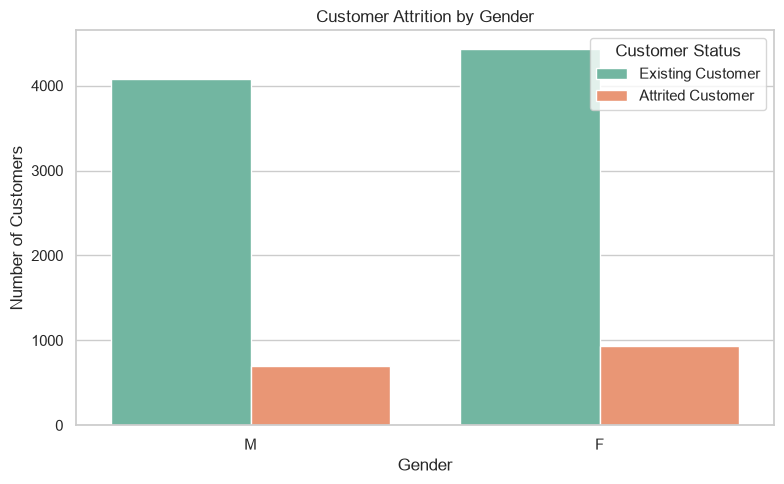

✅ Chart saved to outputs/figures/11_attrition_by_gender.png

📌 Attrition Percentage by Gender


Attrition_Flag,Attrited Customer,Existing Customer
Gender,,
F,17.36,82.64
M,14.62,85.38


In [24]:
# ==========================================
# Customer Attrition by Gender
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Gender",
    hue="Attrition_Flag",
    palette="Set2"
)

plt.title("Customer Attrition by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.legend(title="Customer Status")

plt.tight_layout()

# Save Chart
Path("outputs/figures").mkdir(parents=True, exist_ok=True)

plt.savefig(
    "outputs/figures/11_attrition_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/figures/11_attrition_by_gender.png")

print("\n" + "="*60)
print("📌 Attrition Percentage by Gender")
print("="*60)

display(
    pd.crosstab(
        df_clean["Gender"],
        df_clean["Attrition_Flag"],
        normalize="index"
    ).round(4) * 100
)

## Observation

The gender-wise attrition analysis compares customer retention patterns between male and female customers. By examining the distribution of existing and attrited customers across both genders, this visualization helps identify whether gender has a noticeable influence on customer churn. These insights can support customer segmentation and retention strategy development.

# 👥 Customer Attrition by Age Group

## Objective

Analyze customer attrition across different age groups to identify whether certain age segments are more likely to leave the bank. This analysis helps uncover age-related churn patterns and supports customer retention strategies targeted toward high-risk age groups.

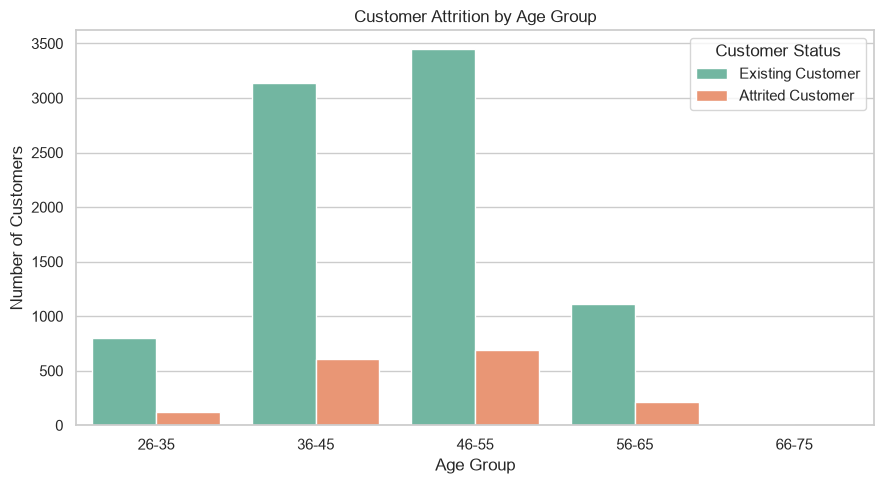

✅ Chart saved to outputs/figures/12_attrition_by_age_group.png

📌 Attrition Percentage by Age Group


Attrition_Flag,Attrited Customer,Existing Customer
Age_Group,,
26-35,13.28,86.72
36-45,16.19,83.81
46-55,16.64,83.36
56-65,15.82,84.18
66-75,20.00,80.00


In [25]:
# ==========================================
# Customer Attrition by Age Group
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Create Age Groups
df_clean["Age_Group"] = pd.cut(
    df_clean["Customer_Age"],
    bins=[25, 35, 45, 55, 65, 75],
    labels=["26-35", "36-45", "46-55", "56-65", "66-75"]
)

plt.figure(figsize=(9,5))

sns.countplot(
    data=df_clean,
    x="Age_Group",
    hue="Attrition_Flag",
    palette="Set2"
)

plt.title("Customer Attrition by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.legend(title="Customer Status")

plt.tight_layout()

# Save Chart
Path("outputs/figures").mkdir(parents=True, exist_ok=True)

plt.savefig(
    "outputs/figures/12_attrition_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/figures/12_attrition_by_age_group.png")

print("\n" + "="*60)
print("📌 Attrition Percentage by Age Group")
print("="*60)

display(
    pd.crosstab(
        df_clean["Age_Group"],
        df_clean["Attrition_Flag"],
        normalize="index"
    ).round(4) * 100
)

## Observation

The age-group attrition analysis highlights how customer churn varies across different age segments. Comparing attrition rates among age groups helps identify customer segments that may require stronger engagement and retention efforts. These insights can support age-specific marketing campaigns and customer relationship strategies.

# 🎓 Customer Attrition by Education Level

## Objective

Analyze customer attrition across different education levels to determine whether educational background influences customer retention. This analysis helps identify education-based churn patterns and provides insights for designing targeted engagement and retention strategies.

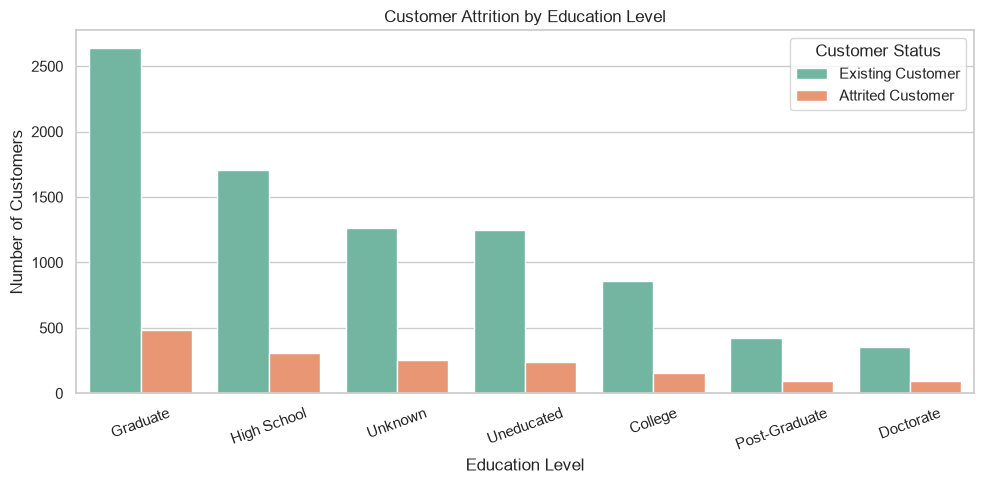

✅ Chart saved to outputs/figures/13_attrition_by_education_level.png

📌 Attrition Percentage by Education Level


Attrition_Flag,Attrited Customer,Existing Customer
Education_Level,,
College,15.20,84.80
Doctorate,21.06,78.94
Graduate,15.57,84.43
High School,15.20,84.80
Post-Graduate,17.83,82.17
Uneducated,15.94,84.06
Unknown,16.85,83.15


In [26]:
# ==========================================
# Customer Attrition by Education Level
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="Education_Level",
    hue="Attrition_Flag",
    palette="Set2",
    order=df_clean["Education_Level"].value_counts().index
)

plt.title("Customer Attrition by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.legend(title="Customer Status")

plt.tight_layout()

# Save Chart
Path("outputs/figures").mkdir(parents=True, exist_ok=True)

plt.savefig(
    "outputs/figures/13_attrition_by_education_level.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/figures/13_attrition_by_education_level.png")

print("\n" + "="*60)
print("📌 Attrition Percentage by Education Level")
print("="*60)

display(
    pd.crosstab(
        df_clean["Education_Level"],
        df_clean["Attrition_Flag"],
        normalize="index"
    ).round(4) * 100
)

## Observation

The education-level attrition analysis compares customer retention across different educational backgrounds. The visualization helps identify whether certain education groups experience relatively higher customer churn, providing useful insights for customer segmentation and personalized retention initiatives.

# 💰 Customer Attrition by Income Category

## Objective

Analyze customer attrition across different income categories to determine whether income level influences customer retention. This analysis helps identify high-risk income segments, understand customer spending behavior, and support data-driven retention strategies for different income groups.

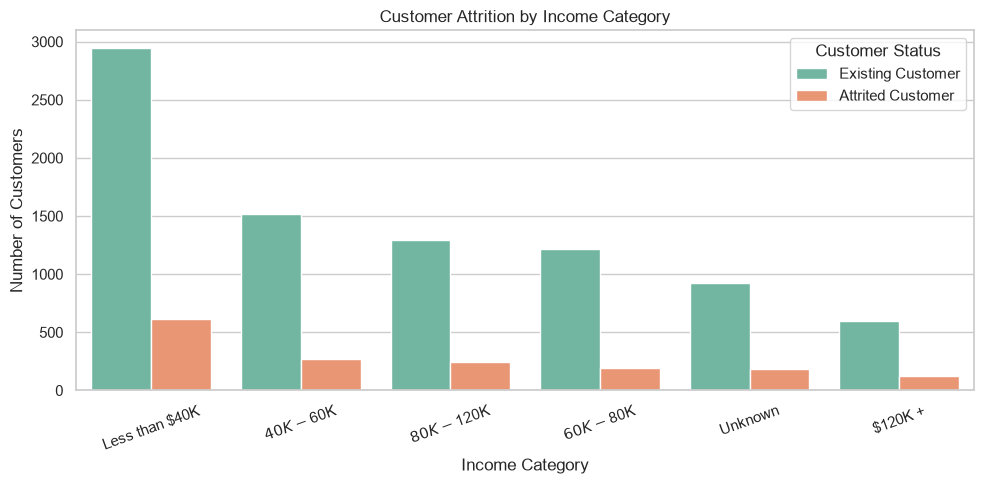

✅ Chart saved to outputs/figures/14_attrition_by_income_category.png

📌 Attrition Percentage by Income Category


Attrition_Flag,Attrited Customer,Existing Customer
Income_Category,,
$120K +,17.33,82.67
$40K - $60K,15.14,84.86
$60K - $80K,13.48,86.52
$80K - $120K,15.77,84.23
Less than $40K,17.19,82.81
Unknown,16.82,83.18


In [27]:
# ==========================================
# Customer Attrition by Income Category
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="Income_Category",
    hue="Attrition_Flag",
    palette="Set2",
    order=df_clean["Income_Category"].value_counts().index
)

plt.title("Customer Attrition by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.legend(title="Customer Status")

plt.tight_layout()

# Save Chart
Path("outputs/figures").mkdir(parents=True, exist_ok=True)

plt.savefig(
    "outputs/figures/14_attrition_by_income_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/figures/14_attrition_by_income_category.png")

print("\n" + "="*60)
print("📌 Attrition Percentage by Income Category")
print("="*60)

display(
    pd.crosstab(
        df_clean["Income_Category"],
        df_clean["Attrition_Flag"],
        normalize="index"
    ).round(4) * 100
)

## Observation

The income-category attrition analysis compares customer retention across different income groups. This visualization helps identify whether customers from specific income segments experience relatively higher churn rates, providing valuable insights for targeted financial products, personalized marketing campaigns, and customer retention strategies.

# 💳 Customer Attrition by Card Category

## Objective

Analyze customer attrition across different credit card categories to determine whether card type influences customer retention. This analysis helps identify high-risk card segments, evaluate customer loyalty across product tiers, and support strategic decisions for premium card offerings and retention programs.

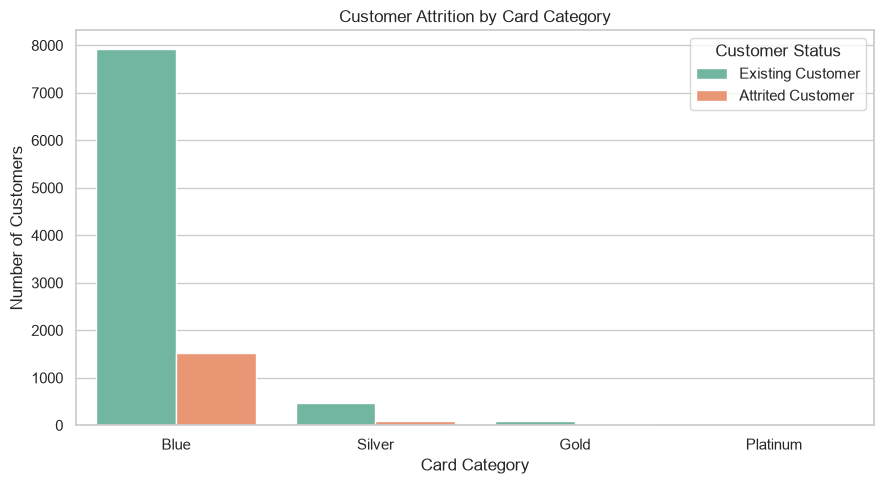

✅ Chart saved to outputs/figures/15_attrition_by_card_category.png

📌 Attrition Percentage by Card Category


Attrition_Flag,Attrited Customer,Existing Customer
Card_Category,,
Blue,16.10,83.90
Gold,18.10,81.90
Platinum,25.00,75.00
Silver,14.77,85.23


In [28]:
# ==========================================
# Customer Attrition by Card Category
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.figure(figsize=(9,5))

sns.countplot(
    data=df_clean,
    x="Card_Category",
    hue="Attrition_Flag",
    palette="Set2",
    order=df_clean["Card_Category"].value_counts().index
)

plt.title("Customer Attrition by Card Category")
plt.xlabel("Card Category")
plt.ylabel("Number of Customers")

plt.legend(title="Customer Status")

plt.tight_layout()

# Save Chart
Path("outputs/figures").mkdir(parents=True, exist_ok=True)

plt.savefig(
    "outputs/figures/15_attrition_by_card_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/figures/15_attrition_by_card_category.png")

print("\n" + "="*60)
print("📌 Attrition Percentage by Card Category")
print("="*60)

display(
    pd.crosstab(
        df_clean["Card_Category"],
        df_clean["Attrition_Flag"],
        normalize="index"
    ).round(4) * 100
)

## Observation

The card-category attrition analysis compares customer retention across different credit card tiers. This visualization helps determine whether premium or standard cardholders exhibit different churn patterns, providing valuable insights for loyalty programs, premium service offerings, and targeted customer retention strategies.

# 🔥 Correlation Heatmap

## Objective

Analyze the relationships among numerical features using a correlation heatmap. This visualization helps identify strong positive and negative correlations, detect redundant variables, and understand how customer attributes interact with one another. These insights support feature selection and deeper business analysis.

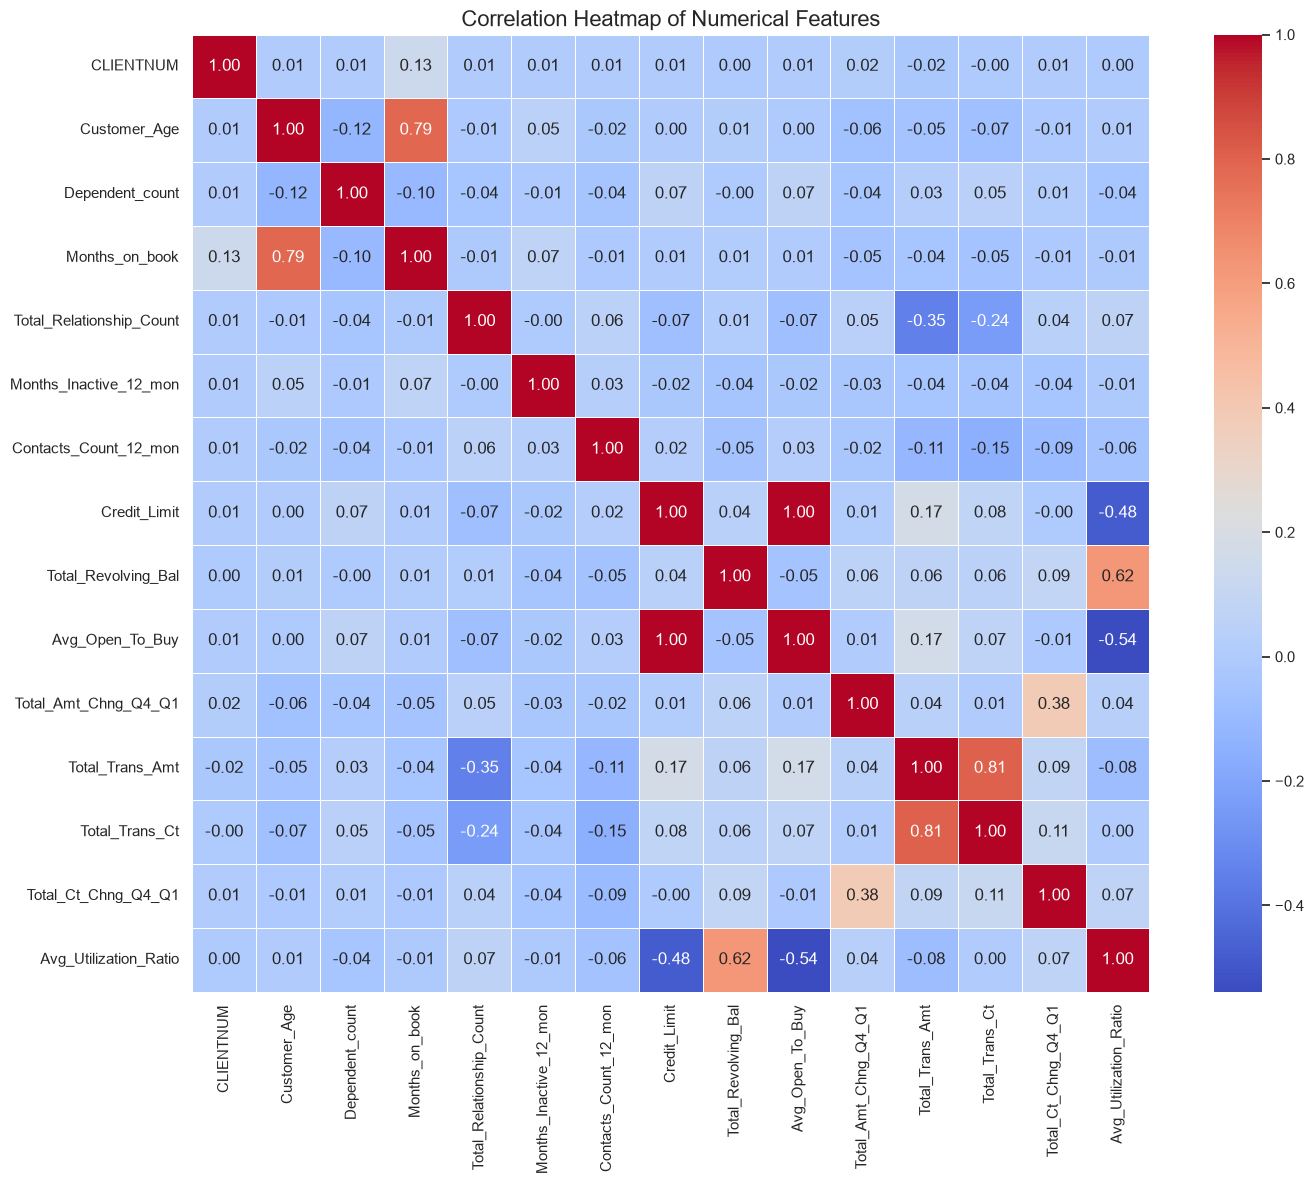

✅ Chart saved to outputs/figures/16_correlation_heatmap.png


In [29]:
# ==========================================
# Correlation Heatmap
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Select only numerical columns
numeric_df = df_clean.select_dtypes(include=["int64", "float64"])

# Correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(15, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)

plt.tight_layout()

# Save Chart
Path("outputs/figures").mkdir(parents=True, exist_ok=True)

plt.savefig(
    "outputs/figures/16_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/figures/16_correlation_heatmap.png")

## Observation

The correlation heatmap provides a comprehensive view of relationships among numerical variables in the dataset. Strong positive correlations indicate features that increase together, while negative correlations reveal inverse relationships. This analysis helps identify redundant variables, understand customer behavior patterns, and support feature selection for predictive modeling and advanced analytics.

# 📈 Feature Correlation with Customer Attrition

## Objective

Analyze the correlation between numerical features and customer attrition by converting the target variable into a numerical format. This visualization identifies the features most strongly associated with customer churn and provides valuable insights for feature importance, business decision-making, and predictive modeling.

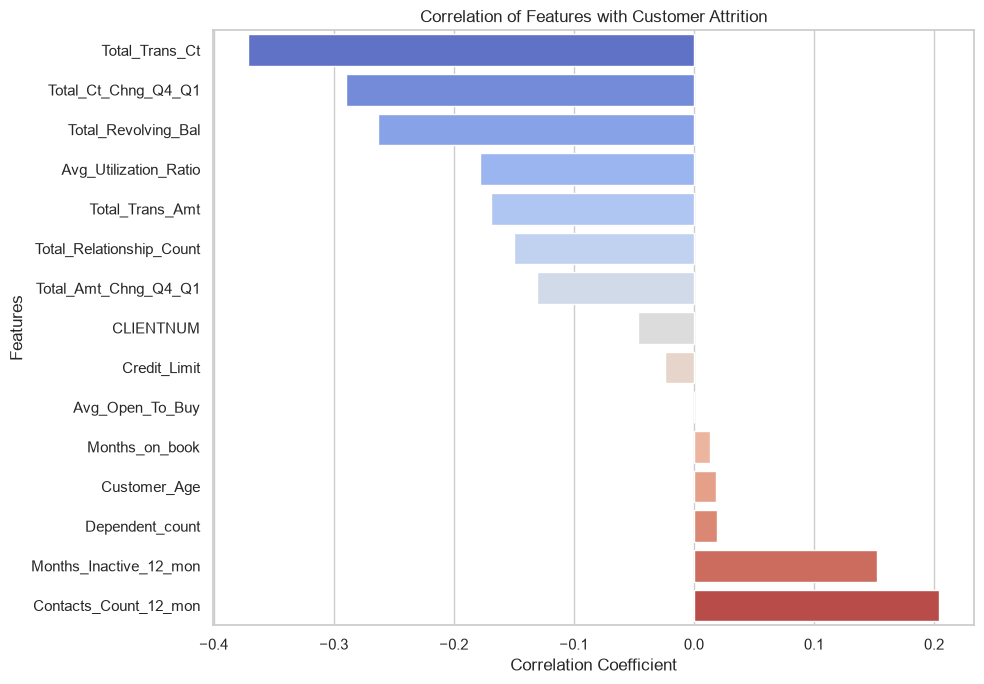

✅ Chart saved to outputs/figures/17_feature_correlation_with_attrition.png


,Correlation
Total_Trans_Ct,-0.371403
Total_Ct_Chng_Q4_Q1,-0.290054
Total_Revolving_Bal,-0.263053
Avg_Utilization_Ratio,-0.178410
Total_Trans_Amt,-0.168598
Total_Relationship_Count,-0.150005
Total_Amt_Chng_Q4_Q1,-0.131063
CLIENTNUM,-0.046430
Credit_Limit,-0.023873
Avg_Open_To_Buy,-0.000285


In [30]:
# ==========================================
# Feature Correlation with Customer Attrition
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Create encoded target variable
df_corr = df_clean.copy()

df_corr["Attrition"] = df_corr["Attrition_Flag"].map({
    "Existing Customer":0,
    "Attrited Customer":1
})

# Select numerical columns
corr = df_corr.select_dtypes(include=["int64","float64"]).corr()

# Correlation with Attrition
attrition_corr = (
    corr["Attrition"]
    .drop("Attrition")
    .sort_values()
)

plt.figure(figsize=(10,7))

sns.barplot(
    x=attrition_corr.values,
    y=attrition_corr.index,
    palette="coolwarm"
)

plt.title("Correlation of Features with Customer Attrition")

plt.xlabel("Correlation Coefficient")

plt.ylabel("Features")

plt.tight_layout()

# Save Chart
Path("outputs/figures").mkdir(parents=True, exist_ok=True)

plt.savefig(
    "outputs/figures/17_feature_correlation_with_attrition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/figures/17_feature_correlation_with_attrition.png")

display(
    attrition_corr.to_frame(name="Correlation")
)

## Observation

The feature-correlation analysis highlights which numerical variables are most strongly associated with customer attrition. Features with higher positive correlations indicate characteristics linked to a greater likelihood of churn, while negative correlations suggest attributes associated with customer retention. These insights help prioritize important variables for predictive modeling and customer retention strategies.

## 🔗 Relationship Analysis (Pairplot)

### Objective

Analyze the relationships among key numerical features while distinguishing customers based on their attrition status. This visualization helps identify patterns, clusters, and potential separations between existing and attrited customers, providing deeper insights into customer behavior before deriving final business recommendations.

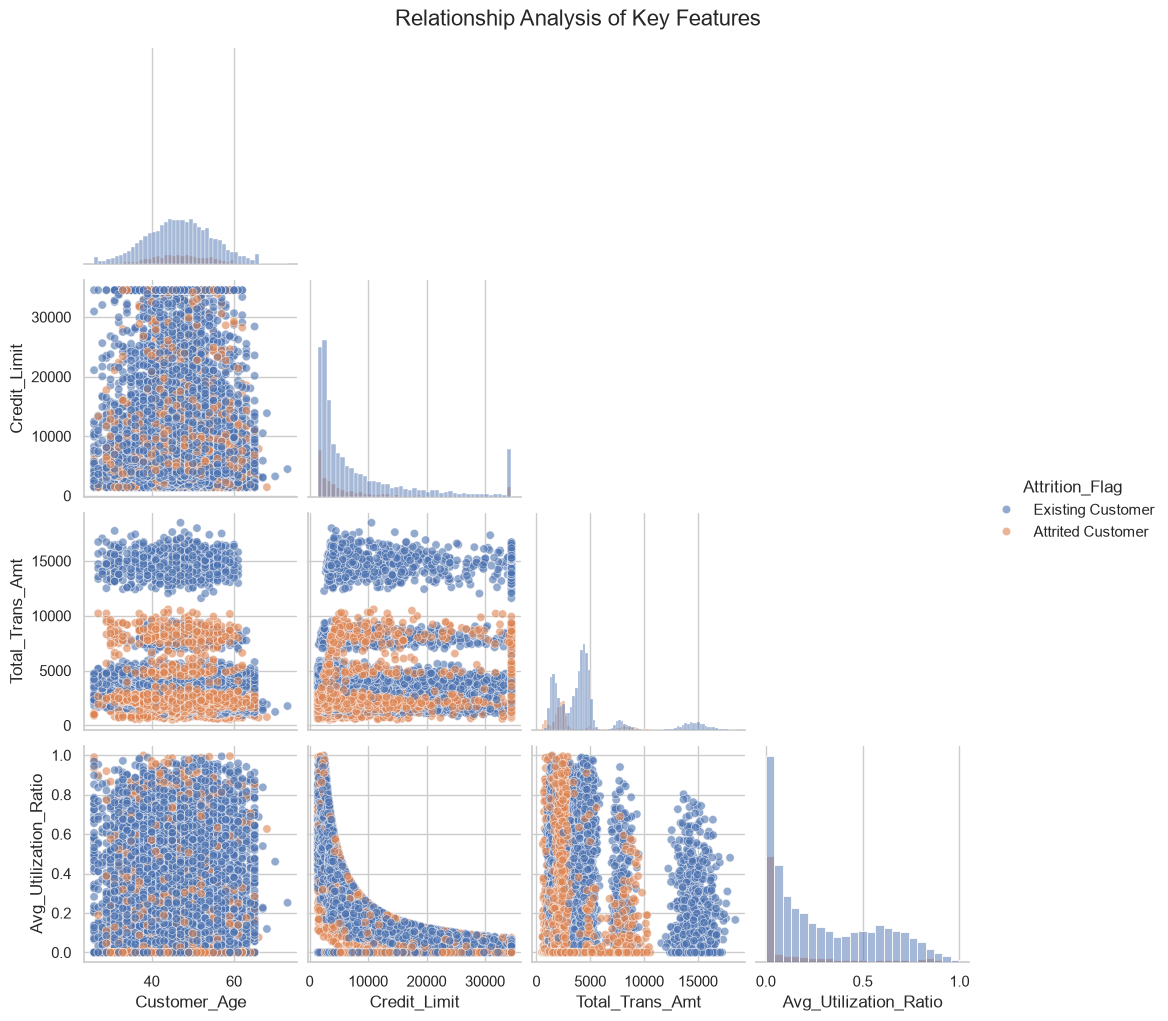

✅ Chart saved to outputs/figures/18_relationship_pairplot.png


In [31]:
# ==========================================
# Relationship Analysis (Pairplot)
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Select important numerical features
pairplot_data = df_clean[
    [
        "Customer_Age",
        "Credit_Limit",
        "Total_Trans_Amt",
        "Avg_Utilization_Ratio",
        "Attrition_Flag",
    ]
]

# Create Pairplot
pair_plot = sns.pairplot(
    pairplot_data,
    hue="Attrition_Flag",
    diag_kind="hist",
    corner=True,
    plot_kws={"alpha": 0.6}
)

pair_plot.fig.suptitle(
    "Relationship Analysis of Key Features",
    y=1.02,
    fontsize=16
)

# Save Figure
Path("outputs/figures").mkdir(parents=True, exist_ok=True)

pair_plot.savefig(
    "outputs/figures/18_relationship_pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/figures/18_relationship_pairplot.png")

### Observation

The pairplot reveals the relationships among important numerical features while comparing existing and attrited customers. Although considerable overlap exists between the two groups, subtle differences can be observed in transaction amount, credit limit, and utilization ratio. These patterns indicate that customer attrition is influenced by multiple interacting factors rather than a single variable, highlighting the importance of multivariate analysis for customer retention strategies.

# 💼 Business Insights

## Objective

Summarize the most important findings discovered during exploratory data analysis and translate them into meaningful business insights. This section highlights customer behavior patterns, attrition trends, spending habits, and opportunities that can help the bank improve customer retention, marketing strategies, and overall business performance.

## 📌 Key Business Insights

### 1. Customer Retention
- Around **84%** of customers are existing customers, while **16%** have left the bank.
- Although the attrition rate is relatively low, reducing this percentage can significantly improve long-term revenue.

---

### 2. Customer Demographics
- Most customers belong to the **40–55 years** age group.
- Female customers slightly outnumber male customers.
- Married customers represent the largest customer segment.

---

### 3. Education & Income
- Graduate customers form the largest educational group.
- Most customers earn **less than $40K annually**, indicating that the bank primarily serves middle-income customers.

---

### 4. Credit Card Usage
- Most customers have **low credit utilization**, indicating responsible credit behavior.
- A small group of customers exhibits very high utilization, which may represent higher financial risk.

---

### 5. Spending Behavior
- Transaction amounts vary widely across customers.
- A small number of customers contribute significantly higher transaction volumes, making them valuable high-value customers.

---

### 6. Attrition Drivers
Correlation analysis suggests that customer attrition is more strongly associated with:

- Lower transaction amounts
- Lower transaction counts
- Lower utilization ratio
- Fewer banking relationships
- More inactive months
- Higher contact frequency with the bank

These features should receive greater attention in customer retention strategies.

---

### 7. Business Opportunity

The bank can improve customer retention by:

- Identifying inactive customers early.
- Rewarding loyal high-value customers.
- Providing personalized offers.
- Encouraging increased card usage.
- Monitoring customers with declining transaction activity.

# 🏁 Final Conclusion

## Objective

Summarize the complete exploratory data analysis process, highlight the key findings, and provide actionable recommendations based on customer behavior and attrition patterns. This conclusion presents the overall business value of the analysis and outlines potential directions for future work.

---

## 📋 Project Summary

This project conducted a comprehensive **Data Cleaning** and **Exploratory Data Analysis (EDA)** on the **BankChurners (Credit Card Customer)** dataset.

The analysis began with a thorough assessment of data quality, where missing values, duplicate records, and inconsistent data types were examined. The dataset was found to be clean, requiring only the removal of two unnecessary Naïve Bayes classifier columns before analysis.

A total of **18 professional visualizations** were created to explore customer demographics, spending behavior, credit utilization, transaction activity, and customer attrition patterns. These visualizations provided meaningful insights into customer characteristics and the factors associated with customer churn.

---

## 🔍 Key Findings

- Approximately **84%** of customers remain active, while around **16%** have left the bank.
- Most customers are between **40 and 55 years** of age.
- Female customers slightly outnumber male customers.
- Graduate and middle-income customers represent the largest customer segments.
- Most customers maintain **low credit utilization**, indicating responsible credit management.
- Customers with lower transaction activity, fewer banking relationships, and longer inactive periods are more likely to leave the bank.
- Correlation analysis shows that customer churn is influenced by multiple behavioral factors rather than a single feature.

---

## 💡 Business Recommendations

- Develop an early-warning system to identify customers at high risk of attrition.
- Launch personalized retention campaigns for inactive customers.
- Reward loyal and high-value customers with exclusive offers and benefits.
- Encourage increased card usage through cashback, reward points, and promotional campaigns.
- Continuously monitor transaction activity and customer engagement to improve retention rates.

---

## 🚀 Future Scope

The analysis can be extended by developing predictive machine learning models such as:

- Logistic Regression
- Decision Tree Classifier
- Random Forest
- XGBoost

These models can help predict customer attrition in advance, allowing the bank to take proactive measures to retain valuable customers.

---

## ✅ Project Outcome

This project successfully transformed raw customer data into meaningful business insights through systematic data cleaning, visualization, and analytical interpretation. The findings support data-driven decision-making for improving customer retention, increasing customer engagement, and optimizing business strategies.

The completed analysis demonstrates practical skills in **Python**, **Pandas**, **NumPy**, **Matplotlib**, **Seaborn**, **Data Cleaning**, **Exploratory Data Analysis (EDA)**, **Data Visualization**, and **Business Insight Generation**, making it a strong portfolio project for aspiring Data Analysts.